# Sleep & Heart Rate: A Time-Series Look at the BIDSleep Dataset

**Case-study and Application of Time Series Analysis on Select-Disciplines**


Submitted by: **`Group 3`** <br>
Members: <br>
`Llesis, Hannah`, `Bitco, Yvonne`, `Sevilla, Emmanuel `, `Gaca, Karl`, `Tion, Cristobal`, `Ruiz, Ross Jervin `




## Background

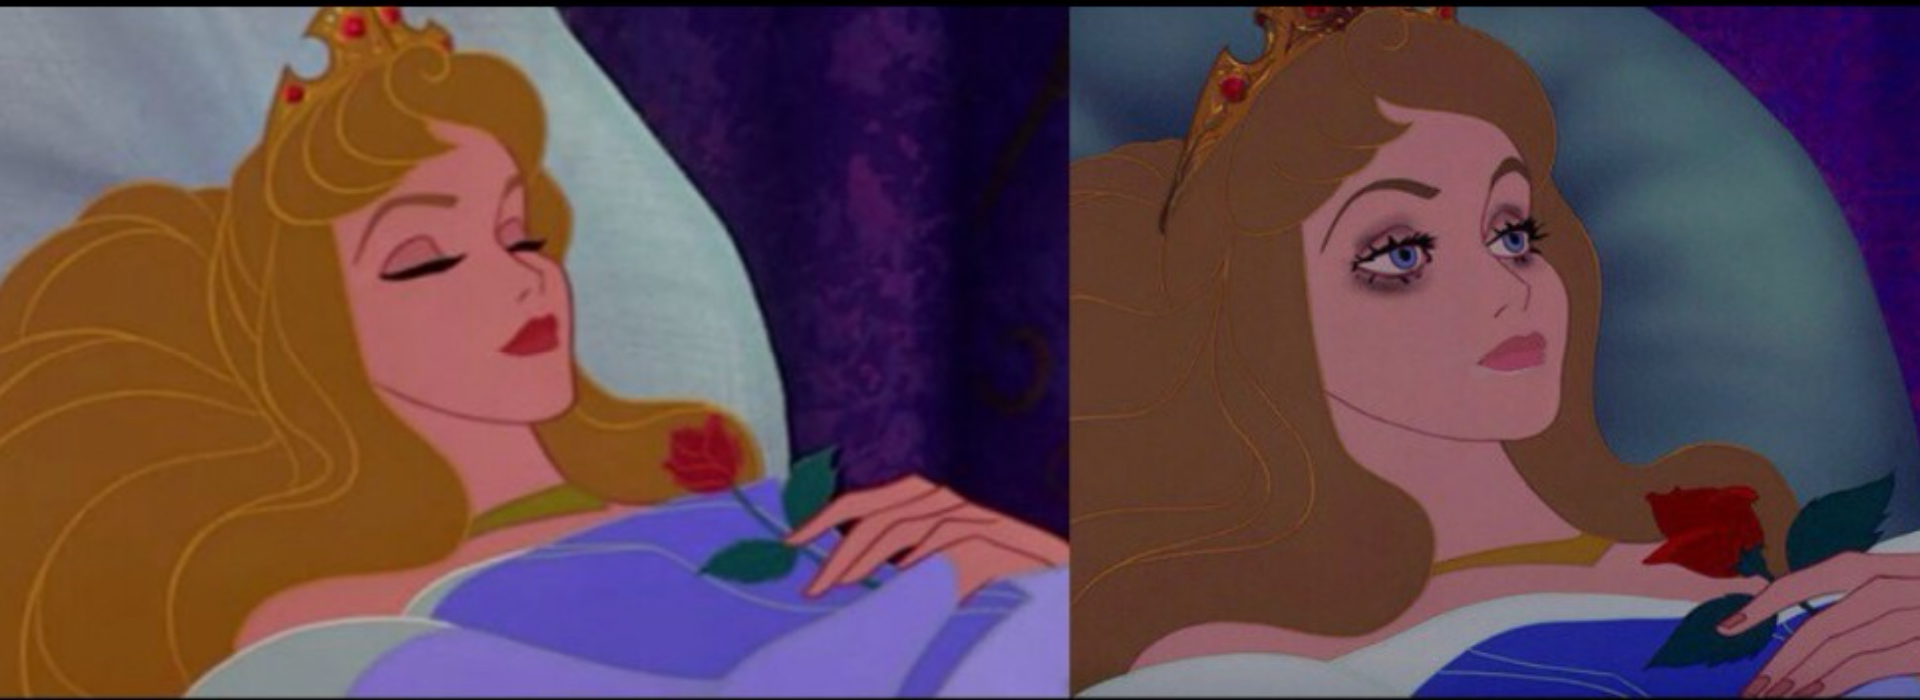

Everyone is familiar with the sleep cycle. You start out awake, then gradually transition into light sleep. As the night continues, you move into deeper sleep before eventually returning to lighter sleep and entering REM. This cycle repeats throughout the night.

**But what actually happens to our body as we move through these stages?**

According to [Sleep Foundation(2025)](https://www.sleepfoundation.org/stages-of-sleep), sleep is divided into different stages:

* **Wake** is when we are still awake and aware of our surroundings.
* **N1** is the transition into light sleep, when we are just beginning to fall asleep.
* **N2** is a deeper stage of light sleep, where our body starts to relax more.
* **N3** is deep sleep, often considered the most restorative stage.
* **REM, or Rapid Eye Movement**, is a stage where brain activity becomes more active and dreaming commonly occurs.

While we move through these stages, our body also changes. Our **heart rate can speed up or slow down**, and **our movement can increase or decreas**e depending on what stage of sleep we are in.

So, this raises an interesting question: **Can we actually see these changes in the data through time?**


## 1. Dataset Introduction

Our dataset is the [**BIDSleep Dataset**](https://physionet.org/content/bidsleep-dataset/1.0.0/) by **Tzu-An Song**, obtained from **[PhysioNet](https://physionet.org/about/database/)**, an open platform that provides access to medical and physiological datasets for research and education.

**BIDSleep** is a sleep-monitoring dataset containing recordings from **47 healthy adults** across **253 nights**. The participants wore an **Apple Watch** and a **Dreem 2 EEG headband** while sleeping.

For each night, the dataset provides three main types of information:

| Data            | What it tells us                                                |
| --------------- | --------------------------------------------------------------- |
| **Heart Rate**  | How fast the person's heart is beating over time                |
| **Movement**    | How much the person moves while sleeping                        |
| **Sleep Stage** | Whether the person is Awake, in light sleep, deep sleep, or REM |


### Why is this time series data?


The heart rate and movement measurements are recorded **at different points in time**, with each observation having a timestamp. This allows us to arrange the data chronologically and observe how the person's heart rate and movement **change throughout the night**.

The sleep-stage labels are also recorded over time, with one sleep-stage label for every **30-second interval**. This allows us to see how the person's sleep progresses from one stage to another.

### Why focus on heart rate?

For this analysis, we will start with **heart rate** because it is the simplest signal to understand and visualize. Unlike the movement data, which contains three different measurements (X, Y, and Z), heart rate gives us a single value at each point in time.

This allows us to focus on the main goal of the activity: **observing how a time series behaves over time**.

## 2. Data Loading

The complete BIDSleep dataset is relatively large, so for this analysis, we will work with a **manageable portion of the dataset**: one participant and one night.

For our analysis, we use:

**`Bidslab00/1/hr.csv`** — contains the participant's heart rate measurements recorded throughout one night.

We will first inspect the data to understand its structure, timestamps, and heart rate values before visualizing how the measurements change over time.


In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.io import loadmat
from urllib.request import urlretrieve
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)

# ---- which recording to analyze ----
SUBJECT = "Bidslab00"
NIGHT = "1"
DOWNLOAD_MOTION = False

DATA_DIR = Path("data") / SUBJECT / NIGHT
DATA_DIR.mkdir(parents=True, exist_ok=True)
BASE_URL = f"https://physionet.org/files/bidsleep-dataset/1.0.0/{SUBJECT}/{NIGHT}/"

files_needed = ["hr.csv", "labels.mat"] + (["motion.csv"] if DOWNLOAD_MOTION else [])
for fname in files_needed:
    fpath = DATA_DIR / fname
    if not fpath.exists():
        print(f"Downloading {fname} ...")
        urlretrieve(BASE_URL + fname, fpath)
    else:
        print(f"Found locally: {fpath}")

In [ ]:
# hr.csv has NO header row: column 1 = Unix timestamp, column 2 = heart rate (bpm)
hr_path = DATA_DIR / "hr.csv"
hr = pd.read_csv(hr_path, header=None, names=["unix_time", "heart_rate_bpm"])
hr = hr.sort_values("unix_time").reset_index(drop=True)
hr.head()

In [ ]:
# labels.mat: sleep-stage annotations + recording start time
labels_path = DATA_DIR / "labels.mat"
mat = loadmat(labels_path)

recStart_str = str(mat["recStart"][0])          # stored as a U.S. Eastern Time string
expert_label = mat["expert_label"][0].astype(int)  # human-corrected sleep stage per 30s epoch
dreem_label = mat["dreem_label"][0].astype(int)     # automatic sleep stage per 30s epoch
n_epochs = len(expert_label)                        # number of 30s epochs in this night

STAGE_NAMES = {0: "Wake", 1: "N1", 2: "N2", 3: "N3", 4: "REM", 5: "Unknown"}

print("recStart (raw string, US/Eastern):", recStart_str)
print("Number of 30-second epochs:", len(expert_label))
print("Epochs = ~", round(len(expert_label) * 30 / 3600, 2), "hours of recording")

## 3. Data Inspection

Before we analyze the heart rate, we first take a look at the data itself. We check:
* what it contains
* how many observations we have
* the time period covered
* how often measurements were recorded
* whether there are any missing values or unusual entries


In [ ]:
print("Shape:", hr.shape)
print("\nDtypes:\n", hr.dtypes)
print("\nMissing values per column:\n", hr.isna().sum())
print("\nDuplicate rows:", hr.duplicated().sum())
hr.describe()

In [ ]:
# Time range covered by hr.csv (still raw Unix seconds at this point)
start_unix, end_unix = hr["unix_time"].min(), hr["unix_time"].max()
span_hours = (end_unix - start_unix) / 3600
print(f"Unix time range: {start_unix:.1f} -> {end_unix:.1f}")
print(f"Span: {span_hours:.2f} hours")
print(f"Row count: {len(hr)}")
print(f"If sampling were a perfectly steady 0.2 Hz, we'd expect ~{int(span_hours*3600*0.2)} rows.")

In [ ]:
# How evenly spaced are the samples, really?
intervals = hr["unix_time"].diff().dropna()
print("Interval between consecutive HR readings (seconds):")
print(intervals.describe())
print(f"\nMedian interval: {intervals.median():.1f} s")
print(f"% of gaps longer than 10s: {(intervals > 10).mean()*100:.1f}%")
print(f"Longest single gap: {intervals.max():.1f} s")

In [ ]:
# Sleep-stage labels: how are the 5 (well, 6 including 'Unknown') categories distributed?
label_counts = pd.Series(expert_label).map(STAGE_NAMES).value_counts()
print("Expert-labeled epoch counts by stage:\n", label_counts)

agreement = (dreem_label == expert_label).mean()
print(f"\nAutomatic (Dreem) vs. expert-corrected label agreement: {agreement*100:.1f}%")

## 4. Data Preprocessing

We then prepare the timestamps and sleep-stage information:

1. **Convert Unix timestamps to datetime** so the heart rate can be plotted over a readable time axis.

In [ ]:
# 1) Convert Unix timestamps to readable UTC datetime
hr["datetime"] = pd.to_datetime(hr["unix_time"], unit="s", utc=True)

2. **Convert the recording start time to UTC** so it uses the same time reference as the heart rate timestamps.

In [ ]:
# 2) Convert the recording start time from US/Eastern to UTC
recStart_utc = pd.Timestamp(recStart_str, tz="US/Eastern").tz_convert("UTC")
print("recStart in UTC:", recStart_utc)
print("First HR sample time (UTC):", hr["datetime"].iloc[0])

3. **Align sleep stages with heart rate** using the recording start time and 30-second sleep-stage intervals.

In [ ]:
# Each sleep stage represents a 30-second interval, computed from this
# night's own recording start time (recStart_utc) and expert labels.
def compute_epoch(ts):
    return int(np.floor((ts - recStart_utc).total_seconds() / 30)) + 1

hr["epoch"] = hr["datetime"].apply(compute_epoch)

def get_stage(epoch):
    if 1 <= epoch <= len(expert_label):
        return STAGE_NAMES[expert_label[epoch - 1]]
    return None

before = len(hr)
hr["sleep_stage"] = hr["epoch"].apply(get_stage)

# Remove HR measurements outside the available sleep-stage labels
hr = hr.dropna(subset=["sleep_stage"]).copy()
print(f"Dropped {before - len(hr)} sample(s) outside the labeled range.")

hr[["datetime", "heart_rate_bpm", "epoch", "sleep_stage"]].head()


4. **Create a 30-second sleep-stage timeline** so we can see how the person's sleep progresses throughout the night.

In [ ]:
# Create a timeline of sleep stages, with one stage for every 30-second epoch
epoch_times = recStart_utc + pd.to_timedelta(np.arange(n_epochs) * 30, unit="s")

stage_timeline = pd.Series(
    [STAGE_NAMES[v] for v in expert_label],
    index=epoch_times,
    name="sleep_stage"
)

stage_timeline.head()

5. **Put the heart-rate measurements into consistent 30-second intervals** so we have an evenly spaced time series for analysis.

In [ ]:
# Resample heart rate into 30-second intervals
hr_indexed = hr.set_index("datetime")["heart_rate_bpm"]
hr_regular_raw = hr_indexed.resample("30s").mean()

missing_bins = hr_regular_raw.isna().sum()
print(f"Empty 30-second bins before filling: {missing_bins} / {len(hr_regular_raw)}")

# Fill missing intervals using linear interpolation
hr_regular = hr_regular_raw.interpolate(limit_direction="both")

print(f"Empty bins after interpolation: {hr_regular.isna().sum()}")

6. **Identify outliers** or unusually high or low heart-rate values using the IQR method.

In [ ]:
q1, q3 = hr["heart_rate_bpm"].quantile([0.25, 0.75])
iqr = q3 - q1
lower_bound, upper_bound = q1 - 1.5 * iqr, q3 + 1.5 * iqr

hr["is_outlier"] = ~hr["heart_rate_bpm"].between(lower_bound, upper_bound)

n_out = hr["is_outlier"].sum()

print(f"IQR bounds: [{lower_bound:.1f}, {upper_bound:.1f}] bpm")
print(f"Flagged as statistical outliers: {n_out} / {len(hr)} ({n_out/len(hr)*100:.1f}%)")

hr.loc[
    hr["is_outlier"],
    ["datetime", "heart_rate_bpm", "sleep_stage"]
].head(10)

## 5. Time-Series Visualization

We visualize the data first to observe how heart rate changes over time. Each plot focuses on a specific aspect of the time series and helps us **identify patterns**, **fluctuations**, and **other characteristics**.

### Quick Background

To give a basic medical context for interpreting the heart rate patterns we will observe in the plots below, it is important to understand that heart rate changes as the body moves through different stages of sleep, as the body's level of activity and nervous system state also change. The expected normal pattern of heart rate in each sleep stages is described below:

| Sleep Stage          | What is happening         | Heart Rate Pattern     |
| -------------------- | ------------------------- | ------------------------------ |
| **Wake**             | Body is active and alert  | Relatively higher              |
| **N1 – Light Sleep** | Body begins to relax      | Begins to decrease             |
| **N2 – Light Sleep** | Body becomes more relaxed | Generally remains lower        |
| **N3 – Deep Sleep**  | Body is deeply relaxed    | Usually lowest                 |
| **REM**              | Brain becomes more active | More variable and may increase |

Source: [Sleep Foundation, 2025](https://www.sleepfoundation.org/physical-health/sleeping-heart-rate)


### Plot 1: Heart Rate Throughout the Night

This shows the participant's heart rate across the entire night, with the different sleep stages shaded in the background, allowing us to see how heart rate changes over time and observe whether its behavior differs as the participant moves through different stages of sleep.

In [ ]:
# Convert time to hours since the recording started
hr["hours"] = (
    hr["datetime"] - recStart_utc
).dt.total_seconds() / 3600

stage_hours = (
    (stage_timeline.index - recStart_utc).total_seconds() / 3600
)

stage_timeline_hours = pd.Series(
    stage_timeline.values,
    index=stage_hours
)

In [ ]:
stage_colors = {"Wake": "#f4a261", "N1": "#e9c46a", "N2": "#a8dadc", "N3": "#264653", "REM": "#e76f51", "Unknown": "#cccccc"}

fig, ax = plt.subplots(figsize=(14, 5))
block_id = (stage_timeline_hours != stage_timeline_hours.shift()).cumsum()

for _, block in stage_timeline_hours.groupby(block_id):
    stage = block.iloc[0]
    start, end = block.index[0], block.index[-1] + (30 / 3600)
    ax.axvspan(start, end, color=stage_colors[stage], alpha=0.35, lw=0)

ax.plot(hr["hours"], hr["heart_rate_bpm"], color="black", lw=0.8)

handles = [plt.Rectangle((0, 0), 1, 1, color=c, alpha=0.35) for c in stage_colors.values()]
ax.legend(handles, stage_colors.keys(), loc="upper right", ncol=6, fontsize=8)

ax.set_xlabel("Hours since recording started")
ax.set_ylabel("Heart rate (bpm)")
ax.set_title(f"Heart rate across the night — {SUBJECT}, night {NIGHT}\n(background shading = sleep stage)")
ax.set_xlim(left=0) # Added to make the x-axis start flush at 0

plt.tight_layout()
plt.show()

### Plot 1.1

**Question: does the same general heart-rate shape repeat night after night?**

Each night starts at a different clock time, so rather than plotting local time (which would misalign the nights), we plot **hours since that night's recording started**. This puts all 7 nights on a comparable axis, stacked so we can visually scan for a repeating shape: a dip into N3 with lower heart rate, a rise into REM, and a climb back up toward waking.

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.io import loadmat
from urllib.request import urlretrieve
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)

# Assume SUBJECT and STAGE_NAMES are already defined in the kernel state
# SUBJECT = "Bidslab00"
# STAGE_NAMES = {0: "Wake", 1: "N1", 2: "N2", 3: "N3", 4: "REM", 5: "Unknown"}

# --- Define the nights to analyze ---
NIGHTS = [str(i) for i in range(1, 8)] # For 7 nights, from '1' to '7'

# --- Dictionaries to store processed data for each night ---
hr_by_night = {}
recStart_utc_by_night = {}
stage_timeline_by_night = {}
expert_label_by_night = {}   # needed by the composition/consistency plots below

for night_idx in NIGHTS:
    # --- Data directories and URLs ---
    DATA_DIR_night = Path("data") / SUBJECT / night_idx
    DATA_DIR_night.mkdir(parents=True, exist_ok=True)
    BASE_URL_night = f"https://physionet.org/files/bidsleep-dataset/1.0.0/{SUBJECT}/{night_idx}/"

    # --- Download files ---
    files_needed_night = ["hr.csv", "labels.mat"]
    for fname in files_needed_night:
        fpath = DATA_DIR_night / fname
        if not fpath.exists():
            print(f"Downloading {fname} for night {night_idx}...")
            urlretrieve(BASE_URL_night + fname, fpath)
        # else:
            # print(f"Found locally: {fpath} for night {night_idx}") # Uncomment for verbose output

    # --- Load hr.csv ---
    hr_path = DATA_DIR_night / "hr.csv"
    hr_current_night = pd.read_csv(hr_path, header=None, names=["unix_time", "heart_rate_bpm"])
    hr_current_night = hr_current_night.sort_values("unix_time").reset_index(drop=True)
    hr_current_night["night"] = night_idx # Add night identifier

    # --- Load labels.mat ---
    labels_path = DATA_DIR_night / "labels.mat"
    mat = loadmat(labels_path)
    recStart_str = str(mat["recStart"][0])
    expert_label = mat["expert_label"][0].astype(int)
    n_epochs = len(expert_label)
    expert_label_by_night[night_idx] = expert_label

    # --- Convert recording start time to UTC ---
    recStart_utc_by_night[night_idx] = pd.Timestamp(recStart_str, tz="US/Eastern").tz_convert("UTC")

    # --- Process hr_current_night DataFrame ---
    hr_current_night["datetime"] = pd.to_datetime(hr_current_night["unix_time"], unit="s", utc=True)

    # Align sleep stages with heart rate
    hr_current_night["epoch"] = hr_current_night["datetime"].apply(
        lambda ts: int(np.floor((ts - recStart_utc_by_night[night_idx]).total_seconds() / 30)) + 1
    )
    # Remove HR measurements outside the available sleep-stage labels
    hr_current_night = hr_current_night[
        (hr_current_night["epoch"] >= 1) & (hr_current_night["epoch"] <= n_epochs)
    ].copy()

    # Add the corresponding sleep stage
    hr_current_night["sleep_stage"] = hr_current_night["epoch"].map(
        lambda k: STAGE_NAMES[expert_label[k - 1]]
    )

    hr_by_night[night_idx] = hr_current_night

    # --- Create a 30-second sleep-stage timeline ---
    epoch_times = recStart_utc_by_night[night_idx] + pd.to_timedelta(np.arange(n_epochs) * 30, unit="s")
    stage_timeline_by_night[night_idx] = pd.Series(
        [STAGE_NAMES[v] for v in expert_label],
        index=epoch_times,
        name="sleep_stage"
    )

# --- Concatenate all individual HR DataFrames into a single one for plotting ---
# This makes the plotting loop more consistent with the user's original structure
combined_hr_df = pd.concat(hr_by_night.values(), ignore_index=True)


# --- Plotting code (adapted from user's provided snippet) ---
stage_colors = {"Wake": "#f4a261", "N1": "#e9c46a", "N2": "#a8dadc",
                 "N3": "#264653", "REM": "#e76f51", "Unknown": "#cccccc"}

fig, axes = plt.subplots(len(NIGHTS), 1, figsize=(13, 2.0 * len(NIGHTS)), sharex=True)

# Ensure axes is an array even if len(NIGHTS) is 1
if len(NIGHTS) == 1:
    axes = [axes]

# Determine global y-limits for consistent scaling
y_min = combined_hr_df["heart_rate_bpm"].quantile(0.01) - 5
y_max = combined_hr_df["heart_rate_bpm"].quantile(0.99) + 5

for ax, night in zip(axes, NIGHTS):
    # Select data for the current night from the combined DataFrame
    sub = combined_hr_df[combined_hr_df["night"] == night]
    rec_start = recStart_utc_by_night[night]
    hours_since_start = (sub["datetime"] - rec_start).dt.total_seconds() / 3600

    tl = stage_timeline_by_night[night]
    tl_hours = (tl.index - rec_start).total_seconds() / 3600

    # This part calculates block_id for plotting colored background spans
    # It assumes tl.values is a 1D array of stage names
    block_id = (tl.values != np.roll(tl.values, 1))
    block_id[0] = True # Ensure the first block always starts
    block_id = np.cumsum(block_id)
    tl_h_series = pd.Series(tl.values, index=tl_hours)

    for _, block in tl_h_series.groupby(block_id):
        stage = block.iloc[0]
        # Calculate start and end for axvspan. Each epoch is 30 seconds.
        # block.index[0] is the start hour of the block.
        # block.index[-1] is the start hour of the last epoch in the block.
        # We need to add 30s (converted to hours) to the last epoch's start time to get the block end.
        start, end = block.index[0], block.index[-1] + (30 / 3600)
        ax.axvspan(start, end, color=stage_colors[stage], alpha=0.35, lw=0)

    ax.plot(hours_since_start, sub["heart_rate_bpm"], color="black", lw=0.6)
    ax.set_ylabel(f"Night {night}", rotation=0, labelpad=35, va="center")
    ax.set_ylim(y_min, y_max) # Use global limits for consistent scaling
    ax.set_xlim(left=0) # Set x-axis limit to start from 0 for each subplot

axes[-1].set_xlabel("Hours since recording start")
handles = [plt.Rectangle((0, 0), 1, 1, color=c, alpha=0.35) for c in stage_colors.values()]
fig.legend(handles, stage_colors.keys(), loc="upper right", ncol=6, fontsize=8, bbox_to_anchor=(0.98, 1.02))
fig.suptitle(f"Heart rate across {len(NIGHTS)} nights -- {SUBJECT}", y=1.0) # Updated title
plt.tight_layout()
plt.show()

### Plot 2: Raw Heart Rate vs. Rolling Mean

This highlights an **8-hour sleep journey**, mapping how cyclicality and non-stationarity guide overnight recovery. The **10-minute rolling mean (crimson)** cuts through high frequency noise to expose a steady baseline trending between **50 and 65 bpm** as the body rests deeper. By smoothing the erratic chatter of the **raw data (light gray)**, this trendline tracks major physiological shifts while leaving **transient anomalies and volatility** intact highlighting the sharp spikes where a sudden movement or brief awakening broke the night's rhythm.

In [ ]:
rolling_10min = hr_indexed.rolling("10min").mean()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot((hr_indexed.index - recStart_utc).total_seconds()/3600, hr_indexed.values, color="lightgray", lw=0.6, label="Raw heart rate")
ax.plot((rolling_10min.index - recStart_utc).total_seconds()/3600, rolling_10min.values, color="crimson", lw=1.8, label="10-minute rolling mean")

ax.legend()
ax.set_xlabel("Hours since recording started")
ax.set_ylabel("Heart rate (bpm)")
ax.set_title("Raw Heart Rate vs. 10-Minute Rolling Mean")

plt.tight_layout()
plt.show()

**The baseline reveals the predictable blueprint of overnight cardiovascular rest**. By decoupling major trends from chaotic, short-lived spikes, it illustrates that our cardiac recovery follows an unhurried, rhythmic cycle of deep decompression rather than a static overnight flatline.

### Plot 3: Heart-rate distribution by sleep stage

This boxplot isolates the **heart-rate distribution across sleep stages**, showing how **cyclicality and non-stationarity** map to deeper rest. The tight boxes for **light and deep sleep (N1, N2, N3)** reveal highly stable baselines around 56 to 60 bpm, capturing the steady trend of physical recovery. In contrast, the wider distributions and high outliers during Wake and REM capture the **noise, volatility, and transient anomalies** of the night marking sudden accelerations from physical movement or vivid dreaming.

In [ ]:
order = ["Wake", "N1", "N2", "N3", "REM"]
data_by_stage = [hr.loc[hr["sleep_stage"] == s, "heart_rate_bpm"] for s in order]

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(data_by_stage, labels=order, showmeans=True)
ax.set_ylabel("Heart rate (bpm)")
ax.set_title("Heart-rate Distribution by Sleep Stage")
plt.tight_layout()
plt.show()

hr.groupby("sleep_stage")["heart_rate_bpm"].agg(["count", "mean", "std", "min", "max"]).reindex(order)

 **The distribution proves our heart responds dynamically to changing subconscious states rather than flatlining overnight.** The clear shifts in median values validate that our internal time-series characteristics are not random noise, but a structured biological rhythm. They show a nervous system that transitions predictably from highly regulated calming zones in deep sleep to sudden bursts of activation during dreaming.

### Plot 4: Sampling Intervals

This plot shows the **time gap between consecutive heart-rate readings**. It helps us check whether the data is sampled at regular intervals or if the gaps vary over time. This is important because some time-series methods work better with evenly spaced observations.

In [ ]:
#Distribution of time gaps between HR readings
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(intervals, bins=40, color="#2a9d8f", edgecolor="white")
ax.set_xlabel("Gap between consecutive samples (seconds)")
ax.set_ylabel("Count")
ax.set_title("Time between consecutive heart-rate readings")
plt.tight_layout()
plt.show()

###Plot 5: Autocorrelation

This bar chart displays the **autocorrelation of a 30 second heart rate series**, capturing how strongly the heart's rhythm hooks into its own recent history. The high **Lag 1 score (0.70)** shows a powerful immediate memory, meaning your heart rate right now is heavily shaped by where it was just 30 seconds ago. As we look across 40 intervals (20 minutes), the slow, steady fade of these bars tracks the gradual, rolling trends of the sleep cycle proving that your heart rate glides smoothly from one state to the next rather than jumping around randomly.

In [ ]:
# Plot 6: Autocorrelation of the regularized 30-second heart-rate series
# Each lag represents another 30 seconds
max_lag = 40  # 40 x 30s = 20 minutes
acf_vals = [hr_regular.autocorr(lag=l) for l in range(1, max_lag + 1)]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(1, max_lag + 1), acf_vals, color="#6d597a")
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("Lag (x 30 seconds)")
ax.set_ylabel("Autocorrelation")
ax.set_title("Autocorrelation of Heart Rate (Regularized 30s Series)")
plt.tight_layout()
plt.show()

print(f"Lag-1 autocorrelation: {acf_vals[0]:.2f}")
print(f"Lag-10 (5 min) autocorrelation: {acf_vals[9]:.2f}")

**This proves the steady momentum of our overnight cardiac rhythms.** By showing that the heart's past behavior strongly influences its future even 20 minutes later, it confirms that overnight heart-rate patterns flow in connected, predictable waves rather than acting as a series of completely random, disconnected events.

## 6. Observations & Time-Series Characteristics

Based on the single-night analysis (Night 1), we can observe several key characteristics of the heart-rate time series.

### 1. Trend

**Plots 1 & 2** show how heart rate changes throughout the night. The raw heart-rate values fluctuate frequently, while the **10-minute rolling mean** smooths these short-term changes and makes the broader pattern easier to observe. Overall, the rolling mean shows a gradual change in heart rate as the night progresses.

### 2. Variability

The raw heart-rate series shows frequent **short-term fluctuations and occasional spikes**. The amount of variation also differs across different parts of the night. The boxplot in **Plot 3** further shows how the heart-rate distribution and variability differ across sleep stages.

### 3. Heart Rate Across Sleep Stages

**Plots 1 & 3** allow us to compare heart-rate behavior across sleep stages. In this recording, heart rate generally appears **higher during Wake and REM** and **lower during N2 and N3**. The distributions also show differences in the amount of variation across stages.

These observations provide physiological context for understanding how heart rate behaves throughout the sleep cycle, although they describe this particular recording and should not be treated as clinical conclusions.

### 4. Sampling Regularity

**Plot 4** shows that the heart-rate measurements are **not perfectly evenly spaced**. While readings are generally frequent, the gaps between consecutive observations vary. This is important because some time-series methods work better with evenly spaced observations, which is why we created a regularized 30-second series.

### 5. Temporal Dependence

**Plot 5** shows strong positive autocorrelation at shorter lags (e.g., Lag-1 autocorrelation of 0.70). This means that heart-rate values are strongly related to their recent past values. This **temporal dependence** is an important characteristic of time-series data.


## 7. Supporting Analysis: Comparison Across 7 Nights

### Plot 6: Sleep-Stage Composition per Night

This stacked bar chart shows the percentage of each night spent in different sleep stages. It allows us to compare how sleep-stage composition varies across the participant's recorded nights.

In [ ]:
stage_order = ["Wake", "N1", "N2", "N3", "REM"]
composition = pd.DataFrame(index=NIGHTS, columns=stage_order, dtype=float)

for night in NIGHTS:
    counts = pd.Series(expert_label_by_night[night]).map(STAGE_NAMES).value_counts()
    total = counts.sum()
    for s in stage_order:
        composition.loc[night, s] = counts.get(s, 0) / total * 100

fig, ax = plt.subplots(figsize=(9, 5))
bottom = np.zeros(len(NIGHTS))
for s in stage_order:
    ax.bar([str(n) for n in NIGHTS], composition[s], bottom=bottom, color=stage_colors[s], label=s)
    bottom += composition[s].values

ax.set_xlabel("Night")
ax.set_ylabel("% of time in stage")
ax.set_title(f"Sleep-stage composition per night -- {SUBJECT}")
ax.legend(loc="upper right", ncol=5, fontsize=8)
plt.tight_layout()
plt.show()


### Plot 7: Night-to-Night Consistency of Stage-Wise Mean Heart Rate

This line graph tracks the **night-to-night consistency of average heart rate across sleep stages**, highlighting how stable each sleep state remains over a week. The remarkably flat **REM line (salmon)** shows a rigid, highly predictable baseline night after night, while the **deep and light sleep lines (N1, N2, N3)** tightly cluster together at the bottom, proving stable physical recovery. In contrast, the highly erratic **Wake line (orange)** captures the true volatility and noise of varying evening routines or sudden nighttime disruptions across the seven days.

In [ ]:
stage_means_by_night = combined_hr_df.groupby(["night", "sleep_stage"])["heart_rate_bpm"].mean().unstack()
stage_means_by_night = stage_means_by_night.reindex(columns=stage_order)

fig, ax = plt.subplots(figsize=(9, 5.5))
for s in stage_order:
    ax.plot(stage_means_by_night.index, stage_means_by_night[s], marker="o",
            color=stage_colors[s], label=s, lw=2)

ax.set_xlabel("Night")
ax.set_ylabel("Mean heart rate (bpm)")
ax.set_xticks(NIGHTS)
ax.set_title(f"Night-to-night consistency of stage-wise mean HR -- {SUBJECT}")
ax.legend(loc="upper right", ncol=5, fontsize=8)
plt.tight_layout()
plt.show()


**The continuous tracking confirms that our internal sleep stages maintain a structured, predictable hierarchy despite daily life variations.** While our waking heart rate swings wildly from day to day, the heart shifts into highly consistent, regulated tempos the moment we enter our deeper subconscious cycles each night.

### Plot 8: Nocturnal Heart-Rate Dip (Wake -> N3) per Night

**The nocturnal heart-rate dip from Wake to N3 deep sleep**, measuring how effectively the cardiovascular system downshifts each night. The data shows a stable **7-night mean dip of 10.6% (dashed red line)**, which serves as a healthy baseline for automatic nighttime decompression. However, the varying bar heights reveal clear day to day volatility ranging from a shallow **4.4% dip on Night 1** up to a deep **18.7% drop on Night 2** highlighting how daily stress, bedtime fatigue, or evening routines directly influence the heart's capacity to completely relax.

In [ ]:
dip_pct = {}
for night in NIGHTS:
    sub = combined_hr_df[combined_hr_df["night"] == night]
    wake_mean = sub.loc[sub["sleep_stage"] == "Wake", "heart_rate_bpm"].mean()
    n3_mean = sub.loc[sub["sleep_stage"] == "N3", "heart_rate_bpm"].mean()
    if pd.notna(wake_mean) and pd.notna(n3_mean) and wake_mean > 0:
        dip_pct[night] = (wake_mean - n3_mean) / wake_mean * 100

nights_avail = list(dip_pct.keys())
vals = [dip_pct[n] for n in nights_avail]
mean_dip = np.mean(vals)

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar([str(n) for n in nights_avail], vals, color="#264653", alpha=0.85, edgecolor="black")
ax.axhline(mean_dip, color="#e76f51", ls="--", lw=1.5, label=f"7-night mean dip ({mean_dip:.1f}%)")
ax.set_xlabel("Night")
ax.set_ylabel("HR dip, Wake -> N3 (%)")
ax.set_title(f"Nocturnal heart-rate dip per night -- {SUBJECT}")
ax.legend()
plt.tight_layout()
plt.show()

print("Nocturnal HR dip by night (%):")
for n, v in dip_pct.items():
    print(f"  Night {n}: {v:.1f}%")
print(f"Mean: {mean_dip:.1f}%,  Std: {np.std(vals):.1f} percentage points")


**This nocturnal percentage tracking captures the changing efficiency of our nightly recovery windows**. While the heart consistently drops into a restorative zone every single night, the wide swings in depth show that our physiological decompression is a dynamic, highly responsive metric rather than a fixed automatic setting.

## Conclusion



*   **The Single-Night Plot (Plot 1):** The individual night plot visually confirms, in a single continuous timeline, the expected physiological changes: heart rate generally decreases as the subject enters deeper sleep (N2, N3) and becomes more variable during REM phases. This plot clearly demonstrates how a crucial physiological marker like heart rate responds in real-time to the body's internal state transitions during sleep.

    The value of this plot is its ability to present a cohesive narrative of a complete sleep cycle, making the abstract concepts of sleep stages tangible through observable heart rate fluctuations. It's the most direct answer to our initial question: 'Can we actually see these changes in the data through time?'

*   **Supporting Observations from Multi-Night Views:** While the single-night plot provides the foundational insight, the multi-night visualizations (Plots 2, 4, 5) serve to validate and contextualize these primary observations. They confirm that the patterns seen in a single night are not isolated events but are consistent and statistically significant characteristics of this individual's physiology across multiple sleep periods. This multi-night consistency reinforces the reliability of the detailed dynamics initially observed in the single-night plot, transforming a one-off observation into robust evidence of a repeatable biological process.